In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../src')

df_raw = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'Shape: {df_raw.shape}')
df_raw.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
print('Data Types')
print(df_raw.dtypes)
print('\nMissing Values')
print(df_raw.isnull().sum())

Data Types
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing Values
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling   

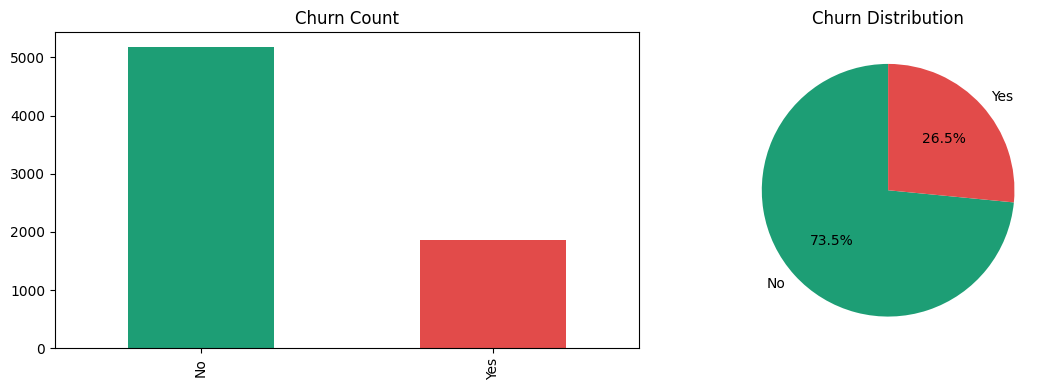

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_raw['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=['#1D9E75','#E24B4A'])
axes[0].set_title('Churn Count')
axes[0].set_xlabel('')

df_raw['Churn'].value_counts().plot(kind='pie', ax=axes[1],
    autopct='%1.1f%%', colors=['#1D9E75','#E24B4A'], startangle=90)
axes[1].set_title('Churn Distribution')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

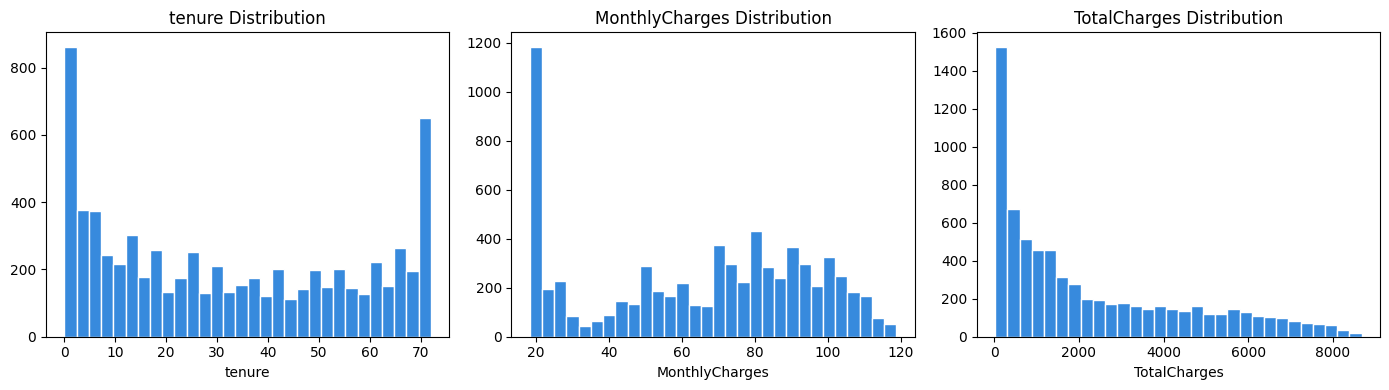

In [4]:
# Numeric distributions
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')
    ax.hist(df_raw[col].dropna(), bins=30, color='#378ADD', edgecolor='white')
    ax.set_title(f'{col} Distribution')
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

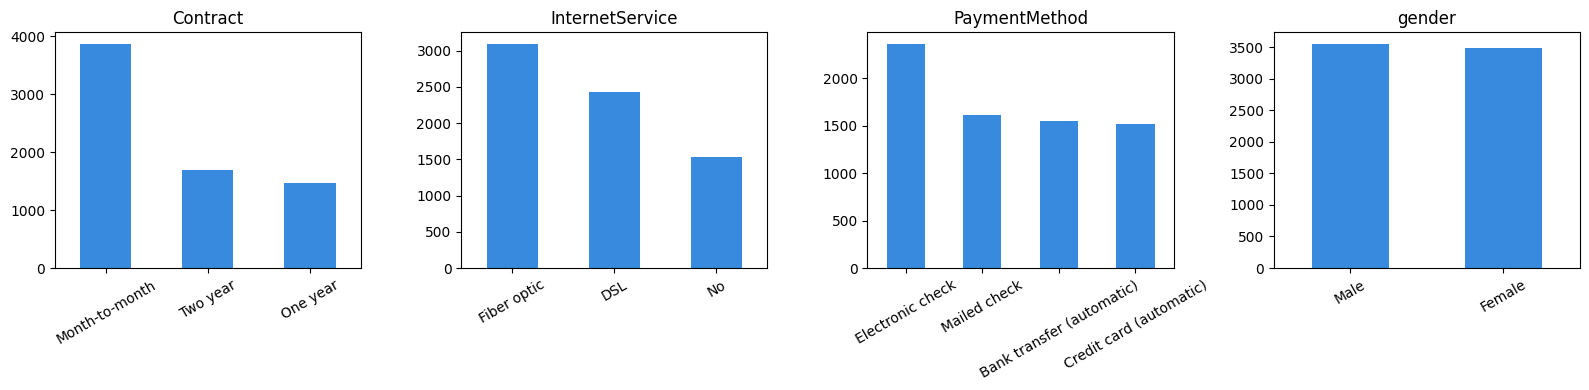

In [5]:
# Categorical columns overview
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'gender']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, cat_cols):
    df_raw[col].value_counts().plot(kind='bar', ax=ax, color='#378ADD')
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()